<font size="+3"><strong>予測精度の簡易的な計算</strong></font>

前ステップで作った色々な配列データについて、簡易的な予測モデルを構築して精度を確認することで、適切なフィルタリング条件を見つける。

---

コード部分の最終更新日: 2024-08-19

 <font color="red" size="+1">注意事項：デバッグ不足</font>
 

---
---
# 理解しておく必要がある事柄
---

## 機械学習に関する基本
- 因果関係と相関関係の違い
- 目的変数と説明変数と係数
- 共線性
- 正規分布、対数化、Box-Cox変換、Yeo-Johnson変換、標準化
- ハイパーパラーメーター、交差検証、過学習
- 学習データ、検証データ、テストデータ
- （回帰）R<sup>2</sup>、MSE、MAE、R<sup>2</sup><sub>test</sub>、R<sup>2</sup><sub>validation</sub>、R<sup>2</sup><sub>cv</sub>
- （回帰）PLS回帰、Lasso回帰、Random foreset回帰、CNN回帰
- （分類）不均衡データ、重み付き学習、サンプリング（+バギング）
- （分類）正解率(Accuracy) 、適合率（Precision）、再現率（Recall）、マシューズ相関係数（MCC）、ROC-AUC、PR-AUC
- （分類）PLS-DS、ロジスティック回帰、Random foreset分類、CNN分類

---
---
# 必要なライブラリのインポート
---

使いまわしているので不要なライブラリのimportを含みます。


In [1]:
import sys
import os
import io
import math
import random
from operator import itemgetter
from collections import Counter
import logging
import json
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import __version__ as matplotlib_version
import seaborn as sns

from scipy import stats
from scipy import __version__ as scipy_version

from sklearn import model_selection, metrics
from sklearn import __version__ as sklearn_version

from sklearn.cross_decomposition import PLSRegression

import sylib

print("python = %d.%d.%d" % sys.version_info[:3])
print("pandas = %s" % pd.__version__)
print("numpy = %s" % np.__version__)
print("scipy = %s" % scipy_version)
print("sklearn = %s" % sklearn_version)
print("matplotlib = %s" % matplotlib_version)
print("seaborn = %s" % sns.__version__)

print("sylib = %s" % sylib.__version__)

# プログレスバーの準備
progress_bar = sylib.utils.ProgressBar()

# Jupyterでlog出力するための特殊な設定
# StreamHandlerの出力先としてsys.stderrを指定している。
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
#     level=logging.DEBUG,
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler]
)
logger=logging.getLogger()

# Ctrl+Enterを押してこのCellを実行してください。うまく動けばpandasのversionなどが表示されます。

python = 3.11.9
pandas = 2.2.2
numpy = 1.26.4
scipy = 1.13.1
sklearn = 1.5.0
matplotlib = 3.9.0
seaborn = 0.13.2
sylib = 0.3.0.dev0+ae18bb2


---
---
# 図の全体的な設定
---


In [2]:
# 一度図を作ってrcParamsを呼び込まないとrcParamsの変更が反映されない場合がある
fig = plt.figure()
plt.close()

# フォントサイズの指定です。
plt_font_size = 16
plt.rcParams['font.size'] = plt_font_size

# フォント名の指定です。フォントはインストールされているものに限ります。
# japanize_matplotlibを用いて日本語を表示している場合、
# フォントを不適切に再設定すると日本語が表示されなくなります。
# Colabを用いる場合はフォントのインストールや登録が必要となりハードルが高いです。
# Colabを用いる場合、初心者は変更せずに使いましょう。
# フォントを変更する場合は以下のコメントアウトを外してください。
# font.family以下はフォント名の設定を色々な要素に反映させるための記述です（変更不要）。
# plt.rcParams['font.serif'] = "DejaVu Sans"
# plt.rcParams['font.family'] = "serif"
# plt.rcParams['mathtext.cal'] = "serif:italic"
# plt.rcParams['mathtext.rm'] = "serif"
# plt.rcParams['mathtext.it'] = "serif:italic"
# plt.rcParams['mathtext.bf'] = "serif:bold"
# plt.rcParams['mathtext.fontset'] = "custom"

# グリッド線などを正しく表示するための設定です。
plt.rcParams['axes.axisbelow'] = True

# 図の解像度を上げるための設定です。
# 表示される図が大きくなるので動作をテストする際には小さい値のほうが見やすいです。
# 最終的に使用する図を出力する際には300など大きな数字を設定しましょう。
# 初期値は72です。
plt.rcParams["figure.dpi"] = 72
# plt.rcParams["figure.dpi"] = 300

# OKという表示があることを確認してください。
print("OK")


OK


---
---
# データの準備
---

## 関数の定義（特徴評価）

ここでは選択するカテゴリーごとに独立したDataFrameを作る関数を定義しています。

Box-Cox変換を行う場合は、0以下が出現しないように、偽カウントの1を加えるなどの工夫をしましょう。Yeo-Johnson変換を行う場合は、最小値と最大値の差が小さくならないように、1000分率を使うなどの工夫をしましょう。

独自の評価項目については各自で関数を追加してください。

<br><font size="+1" color="#FF0000"><b>十分にデバッグできていないのでバグがないか各自でも確認してください。</b></font><br>


In [3]:
def eval_length(seq_list, region_name):
    feat_df = pd.DataFrame(
        {
            region_name+".Length": [len(seq) for seq in seq_list]
        }
    )
    return feat_df


def eval_kmer_freq(seq_list, region_name, is_rna_seq=True, k=1):
    # kmerの数のほうが精度が出る場合があるが、数は長さの要素が入るため、
    # 考察が困難になる。そのため、長さで補正した出現頻度のほうが良い
    count_dict = sylib.sequtils.count_nuc_k_mer_of_seq_list(
        seq_list, is_rna_seq=is_rna_seq, k=k
    )
    feat_df = pd.DataFrame(
        {
            "%s.%s-freq" % (region_name, key): count_dict[key]
            for key in count_dict
        }
    )
    seq_len_sr = pd.Series([len(seq) for seq in seq_list])
    seq_len_sr[seq_len_sr==0] = 1
    for col_name in feat_df.columns:
        feat_df[col_name] /= seq_len_sr
        # Yeo-Johnson変換を行うことも想定して1000分率にする
        feat_df[col_name] *= 1000
    return feat_df


def eval_s_freq(seq_list, region_name):
    # S = G or Cの塩基の出現頻度
    # Sではない = W（A or T/U）なのでWも考慮しているのと同じ
    v_list = []
    for seq in seq_list:
        if len(seq) == 0:
            v_list.append(0.0)
        else:
            # Yeo-Johnson変換を行うことも想定して1000分率にする
            v_list.append(
                (seq.count("G")+seq.count("C"))
                / len(seq) * 1000
            )
    feat_df = pd.DataFrame(
        {"%s.S-freq" % region_name: v_list}
    )
    return feat_df


def eval_y_freq(seq_list, region_name):
    # Y = T (U) or Cの塩基の出現頻度
    # Yではない = R（A or G）なのでRも考慮しているのと同じ
    v_list = []
    for seq in seq_list:
        if len(seq) == 0:
            v_list.append(0.0)
        else:
            # Yeo-Johnson変換を行うことも想定して1000分率にする
            v_list.append(
                (seq.count("T")+seq.count("U")+seq.count("C"))
                / len(seq) * 1000
            )
    feat_df = pd.DataFrame(
        {"%s.Y-freq" % region_name: v_list}
    )
    return feat_df


def eval_k_freq(seq_list, region_name):
    # K = G or T (U)の塩基の出現頻度
    # Kではない = M（A or C）なのでMも考慮しているのと同じ
    v_list = []
    for seq in seq_list:
        if len(seq) == 0:
            v_list.append(0.0)
        else:
            # Yeo-Johnson変換を行うことも想定して1000分率にする
            v_list.append(
                (seq.count("G")+seq.count("T")+seq.count("U"))
                / len(seq) * 1000
            )
    feat_df = pd.DataFrame(
        {"%s.K-freq" % region_name: v_list}
    )
    return feat_df


def eval_n_uaug(utr5_seq_list, region_name, is_rna_seq=True):
    # upstream AUG
    if is_rna_seq:
        feat_df = pd.DataFrame(
            {"%s.uAUG" % region_name: [seq.count("AUG") for seq in utr5_seq_list]}
        )
    else:
        feat_df = pd.DataFrame(
            {"%s.uATG" % region_name: [seq.count("ATG") for seq in utr5_seq_list]}
        )
    return feat_df


def eval_n_uorf(utr5_seq_list, region_name, is_rna_seq=True):
    # Overlapping uORFに本当に終止コドンが登場しているのかは見ていないが、
    # おそらくほぼすべてのuORFには終止コドンが出現している
    feat_df_dict = {
        "%s.uORF-NO" % region_name: [],  # Non-Overlapping uORF
        "%s.uORF-IO" % region_name: [],  # In-flame Overlapping uORF
        "%s.uORF-OO" % region_name: [],  # Out-of-flame Overlapping uORF
    }
    if is_rna_seq:
        start_codon = "AUG"
        stop_codons = {"UAA", "UGA", "UAG"}
    else:
        start_codon = "ATG"
        stop_codons = {"TAA", "TGA", "TAG"}
    for seq in utr5_seq_list:
        seq_len = len(seq)
        n_no, n_io, n_oo = 0, 0, 0
        for i in range(seq_len-3+1):
            if seq[i:i+3] ==start_codon:
                has_stop = False
                for j in range(i+3, seq_len-3+1, 3):
                    if seq[j:j+3] in stop_codons:
                        has_stop = True
                        break
                if has_stop:
                    n_no += 1
                elif (seq_len-i) % 3 == 0:
                    n_io += 1
                else:
                    n_oo += 1
        feat_df_dict["%s.uORF-NO" % region_name].append(n_no)
        feat_df_dict["%s.uORF-IO" % region_name].append(n_io)
        feat_df_dict["%s.uORF-OO" % region_name].append(n_oo)
    return pd.DataFrame(feat_df_dict)


def eval_n_daug(utr3_seq_list, region_name, is_rna_seq=True):
    # downstream AUG
    if is_rna_seq:
        feat_df = pd.DataFrame(
            {"%s.dAUG" % region_name: [seq.count("AUG") for seq in utr3_seq_list]}
        )
    else:
        feat_df = pd.DataFrame(
            {"%s.dATG" % region_name: [seq.count("ATG") for seq in utr3_seq_list]}
        )
    return feat_df


def eval_n_dorf(utr3_seq_list, region_name, is_rna_seq=True):
    # downstream ORF
    feat_df_dict = {
        "%s.dORF" % region_name: [],  # normal dORF
        "%s.dORF-NS" % region_name: [],  # dORF with no Stop codon
    }
    if is_rna_seq:
        start_codon = "AUG"
        stop_codons = {"UAA", "UGA", "UAG"}
    else:
        start_codon = "ATG"
        stop_codons = {"TAA", "TGA", "TAG"}
    for seq in utr3_seq_list:
        # polyAにまたがる終始コドンの存在を考慮
        seq += "AA"
        seq_len = len(seq)
        n_no, n_ns = 0, 0
        for i in range(seq_len-3+1):
            if seq[i:i+3] == start_codon:
                has_stop = False
                for j in range(i+3, seq_len-3+1, 3):
                    if seq[j:j+3] in stop_codons:
                        has_stop = True
                        break
                if has_stop:
                    n_no += 1
                else:
                    n_ns += 1
        feat_df_dict["%s.dORF" % region_name].append(n_no)
        feat_df_dict["%s.dORF-NS" % region_name].append(n_ns)
    return pd.DataFrame(feat_df_dict)


def eval_codon_usage(cds_seq_list, region_name, is_rna_seq=True, should_remove_stop_codons=False):
    # Codon-usage
    # Codonの出現頻度のほうが精度が高くなることも多いが、
    # Codonの出現頻度にはアミノ酸の数も影響するため、純粋なCodonの選択の影響が分かりにくく、
    # 解釈性が下がってしまう。解釈性を求めるならUsageの方が良い。
    mer3_list = sylib.sequtils.get_k_mer_nuc_list(3, is_rna_seq=is_rna_seq)
    aa_codon_dict = sylib.sequtils.get_aa_codon_dict(is_rna_seq=is_rna_seq, code_type="3-letter")

    n_codons_dict = {mer3: [0]*len(cds_seq_list) for mer3 in mer3_list}
    for i, cds_seq in enumerate(cds_seq_list):
        for j in range(0, len(cds_seq), 3):
            seq_part = cds_seq[j:j+3]
            n_codons_dict[seq_part][i] += 1
    codons_df = pd.DataFrame(n_codons_dict)
    usage_df_dict = {}
    for aa, codon_list in aa_codon_dict.items():
        aa_sr = pd.Series([0]*len(cds_seq_list))
        for codon in codon_list:
            aa_sr += codons_df[codon]
        # 0除算エラー対策で0を1に
        aa_sr[aa_sr==0] = 1
        for codon in codon_list:
            # Yeo-Johnson変換を行うことも想定して1000分率にする
            usage_df_dict["%s.%s-%s" % (region_name, aa, codon)] = (
                codons_df[codon]/aa_sr*1000
            )
    # コドンが1つしかないアミノ酸や終止コドンを削除
    if is_rna_seq:
        del usage_df_dict["%s.Met-AUG" % region_name]
        del usage_df_dict["%s.Trp-UGG" % region_name]
        if should_remove_stop_codons:
            del usage_df_dict["%s.Ter-UAA" % region_name]
            del usage_df_dict["%s.Ter-UGA" % region_name]
            del usage_df_dict["%s.Ter-UAG" % region_name]
    else:
        del usage_df_dict["%s.Met-ATG" % region_name]
        del usage_df_dict["%s.Trp-TGG" % region_name]
        if should_remove_stop_codons:
            del usage_df_dict["%s.Ter-TAA" % region_name]
            del usage_df_dict["%s.Ter-TGA" % region_name]
            del usage_df_dict["%s.Ter-TAG" % region_name]
    return pd.DataFrame(usage_df_dict)


def concat_df(x_df_dict, key_list):
    concat_df_list = [x_df_dict[key] for key in key_list]
    n_data_set = set([len(x_df) for x_df in concat_df_list])
    x_df = pd.concat(concat_df_list, axis=1)
    n_data_set.add(len(x_df))
    if len(n_data_set) != 1:
        raise Exception("concat_df: len(n_data_set) != 1")
    return x_df


def eval_feats(seq_df):
    utr5_seq_col = "5'UTR"
    cds_seq_col = "CDS"
    utr3_seq_col = "3'UTR"

    x_feat_df_dict = {}

    for region_name, seq_col in zip(["5'UTR", "CDS", "3'UTR"], [utr5_seq_col, cds_seq_col, utr3_seq_col]):
        # Length
        x_feat_df_dict[region_name+".Length"] = eval_length(seq_df[seq_col], region_name)

        # K-mer frequency
        for k in [1, 2]:
            score_name = "%s.%s-mer-freq" % (region_name, k)
            x_feat_df_dict[score_name] = eval_kmer_freq(seq_df[seq_col], region_name, is_rna_seq=True, k=k)

        # S, Y, K frequency
        x_feat_df_dict[region_name+".S-freq"] = eval_s_freq(seq_df[seq_col], region_name)
        x_feat_df_dict[region_name+".Y-freq"] = eval_y_freq(seq_df[seq_col], region_name)
        x_feat_df_dict[region_name+".K-freq"] = eval_k_freq(seq_df[seq_col], region_name)

        # uORFやCodon-usageなど領域ごとに特有の特徴の評価
        if region_name == "5'UTR":
            x_feat_df_dict["5'UTR.uAUG"] = eval_n_uaug(seq_df[seq_col], region_name, is_rna_seq=True)
            x_feat_df_dict["5'UTR.uORF"] = eval_n_uorf(seq_df[seq_col], region_name, is_rna_seq=True)
        elif region_name == "CDS":
            # 1配列につき、どれかが1個しか出現しない終止コドンは、重要性も低いことが多く
            # 取り除かれる場合もある
            x_feat_df_dict["CDS.Codon-usage"] = eval_codon_usage(
                seq_df[seq_col], region_name, is_rna_seq=True, should_remove_stop_codons=True
            )
        elif region_name == "3'UTR":
            x_feat_df_dict["3'UTR.dAUG"] = eval_n_daug(seq_df[seq_col], region_name, is_rna_seq=True)
            x_feat_df_dict["3'UTR.dORF"] = eval_n_dorf(seq_df[seq_col], region_name, is_rna_seq=True)
    x_feat_df = concat_df(x_feat_df_dict, x_feat_df_dict.keys())
    return x_feat_df


## 関数の定義（学習）


In [4]:
def detect_outliers(
    xformed_train_array, xformed_test_array, removal_method,
    z_score_expected_n=0.5
):
    # 必ずz-scoreに変換した数値を使ってください。
    # `sylib.utils.calc_xform_param_and_xform_array`なら`should_stdzn=True`です。
    if removal_method is None:
        # Noneの場合、外れ値の除去は行いません。
        train_bool_array = np.ones(len(xformed_train_array), dtype=bool)
        test_bool_array = np.ones(len(xformed_test_array), dtype=bool)
    elif removal_method == "Z-score":
        min_thresh = stats.norm.ppf((z_score_expected_n/2) / len(xformed_train_array), loc=0, scale=1)
        max_thresh = -min_thresh
        train_bool_array = (xformed_train_array >= min_thresh) & (xformed_train_array <= max_thresh)
        test_bool_array = (xformed_test_array >= min_thresh) & (xformed_test_array <= max_thresh)
    return train_bool_array, test_bool_array


def xform_and_remove_outliers(
    y_train, y_test, x_train, x_test, g_train=None, g_test=None,
    xform_method="yeo-johnson", outlier_removal_method="Z-score", z_score_expected_n=0.5,
    outlier_det_col_list=["5'UTR.Length", "CDS.Length", "3'UTR.Length"]
):
    # 外れ値の判定用の変換
    pre_y_train, y_xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
        y_train.copy(), xform_method=xform_method, should_stdzn=True
    )
    pre_y_test = sylib.utils.xform_array(y_test.copy(), **y_xform_kwargs)

    # 外れ値の判定
    train_bool_array, test_bool_array = detect_outliers(
        pre_y_train, pre_y_test, outlier_removal_method,
        z_score_expected_n=z_score_expected_n
    )

    if len(outlier_det_col_list) > 0:
        for col_name in outlier_det_col_list:
            if x_train[col_name].var() == 0:
                continue

            xformed_train_array, xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
                x_train[col_name].copy(), xform_method=xform_method, should_stdzn=True
            )
            xformed_test_array = sylib.utils.xform_array(x_test[col_name].copy(), **xform_kwargs)
            temp_train_bool_array, temp_test_bool_array = detect_outliers(
                xformed_train_array, xformed_test_array, outlier_removal_method,
                z_score_expected_n=z_score_expected_n
            )
            train_bool_array &= temp_train_bool_array
            test_bool_array &= temp_test_bool_array
        logger.info("Number of all outliers in trainning data = %s" % (len(y_train)-sum(train_bool_array)))
        logger.info("Number of all outliers in test data      = %s" % (len(y_test)-sum(test_bool_array)))

    # 外れ値を除去する
    y_train = y_train[train_bool_array]
    y_test = y_test[test_bool_array]
    if g_train is not None:
        g_train = g_train[train_bool_array]
        g_test = g_test[test_bool_array]
    x_train = x_train[train_bool_array].copy()
    x_test = x_test[test_bool_array].copy()

    # 外れ値を除去した後のデータで変換したものを用いる
    y_train, y_xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
        y_train, xform_method=xform_method, should_stdzn=True
    )
    y_test = sylib.utils.xform_array(y_test, **y_xform_kwargs)

    x_xform_param_dict = {}
    for col_name in x_train.columns:
        if x_train[col_name].var() == 0:
            # 分散が0、つまり全部同じ数値の場合、数値の大小がなく係数を計算できない
            # そのため削除する
            del x_train[col_name]
            del x_test[col_name]
            logger.warning(
                "%s was removed because the variance is 0." % col_name
            )
            x_xform_param_dict[col_name] = None
            continue
        # 最も出現数が多い値を取得
        most_common_key, most_common_n = Counter(x_train[col_name]).most_common()[0]
        # 数値のバリエーションが低い場合、その特徴の影響はうまく計算できない可能性があります。
        for p in [0.99, 0.9, 0.75, 0.5]:
            if most_common_n/len(x_train) > p:
                logger.warning(
                    "The ratio of `%s` in '%s' is greater than %s%% (%s%%)."
                    % (most_common_key, col_name, round(p*100), round(most_common_n/len(x_train)*100, 2))
                )
                break
        if len(set( x_train[col_name])) == 2:
            # 値が2種類しかない場合、Yeo-Johnson変換する意味がないので行わない
            x_train[col_name], xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
                x_train[col_name], xform_method=None, should_stdzn=True
            )
        else:
            x_train[col_name], xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
                x_train[col_name], xform_method=xform_method, should_stdzn=True
            )
        x_test[col_name] = sylib.utils.xform_array(x_test[col_name], **xform_kwargs)
        x_xform_param_dict[col_name] = xform_kwargs
    return y_train, y_test, x_train, x_test, g_train, g_test, y_xform_kwargs, x_xform_param_dict


def calc_pred_accuracy(seq_df, score_col_name, group_col_name, outlier_removal_method=None):
    x_feat_df = eval_feats(seq_df)

    y_array = np.array(seq_df[score_col_name])
    test_data_ratio = 0.2

    if group_col_name is None:
        n_data = len(seq_df)
        n_test = int(round(n_data*test_data_ratio))
        n_train = n_data - n_test
        x_train, x_test, y_train, y_test = model_selection.train_test_split(
            x_feat_df, y_array, random_state=0, test_size=n_test
        )
        print("n_data = %s, n_train = %s, n_test = %s" % (n_data, n_train, n_test))
        g_train, g_test = None, None
    else:
        g_sr = seq_df[group_col_name]
        gss = model_selection.GroupShuffleSplit(n_splits=1, test_size=test_data_ratio, random_state=0)
        train_idx_array, test_idx_array = list(gss.split(x_feat_df, y_array, g_sr))[0]
        x_train = x_feat_df.iloc[train_idx_array, :].copy()
        y_train = y_array[train_idx_array]
        g_train = g_sr[train_idx_array]
        x_test = x_feat_df.iloc[test_idx_array, :].copy()
        y_test = y_array[test_idx_array]
        g_test = g_sr[test_idx_array]
        print(
            "n_data = %s (%s groups), n_train = %s (%s groups), n_test = %s (%s groups)"
            % (len(g_sr), len(set(g_sr)), len(g_train), len(set(g_train)), len(g_test), len(set(g_test)))
        )

    (
        y_train, y_test, x_train, x_test, g_train, g_test, y_xform_kwargs, x_xform_param_dict
    ) = xform_and_remove_outliers(
        y_train, y_test, x_train, x_test, g_train, g_test,
        xform_method="yeo-johnson", outlier_removal_method=outlier_removal_method, z_score_expected_n=0.5,
        outlier_det_col_list=["5'UTR.Length", "CDS.Length", "3'UTR.Length"]
    )

    # 交差検証の手法の定義
    if group_col_name is None:
        # cv = model_selection.LeaveOneOut()
        cv = model_selection.KFold(n_splits=10, shuffle=True, random_state=0)
    else:
        # cv = model_selection.LeaveOneGroupOut().split(x_train, y_train, g_train)
        cv = model_selection.GroupKFold(n_splits=10).split(x_train, y_train, g_train)

    # 交差検証にて調査するハイパーパラメーターの定義
    n_comp_list = list(range(1, min(10, x_train.shape[1]+1)))
    gs_param = {"n_components": n_comp_list}

    # 交差検証による最適な成分数の解析
    model = PLSRegression()
    gs = model_selection.GridSearchCV(model, gs_param, cv=cv, refit=True, verbose=1)
    gs.fit(x_train, y_train)
    cv_results = gs.cv_results_
    best_params = gs.best_params_
    cv_score = gs.best_score_
    model = gs.best_estimator_

    # 予測結果の表示
    pred_y_train = model.predict(x_train)
    pred_y_test = model.predict(x_test)
    if pred_y_train.ndim == 2:
        pred_y_train = pred_y_train[:, 0]
        pred_y_test = pred_y_test[:, 0]
    peason_r_test, _ = stats.pearsonr(y_test, pred_y_test)
    r2_train = metrics.r2_score(y_train, pred_y_train)
    r2_test = metrics.r2_score(y_test, pred_y_test)
    return cv_score, r2_train, r2_test, n_train, n_test, y_train, pred_y_train, y_test, pred_y_test


---
---
# 処理の実行（通常条件）
---

前ステップで作った色々な配列データについて、簡易的な予測モデルを構築して精度を確認している。精度の評価には基本的にR2cv（CV-score）を参照すること。なお、本当はやっちゃだめだけどテストデータでの検証結果も載せている。


2024-08-26 11:36:18,464     INFO: Seq data |   name = AT22.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:36:18,465     INFO: Seq data |    md5 = de853db935653b260b9f298b3d5e15e1
2024-08-26 11:36:18,465     INFO: Seq data | md5_gz = d82f39bf3b2742b5a916a76a64cfde64
2024-08-26 11:36:20,182     INFO: Number of all outliers in trainning data = 22
2024-08-26 11:36:20,182     INFO: Number of all outliers in test data      = 10
2024-08-26 11:36:20,325  WARNING: The ratio of `0` in '5'UTR.uAUG' is greater than 75% (81.7%).
2024-08-26 11:36:20,329  WARNING: The ratio of `0` in '5'UTR.uORF-NO' is greater than 75% (83.98%).
2024-08-26 11:36:20,332  WARNING: The ratio of `0` in '5'UTR.uORF-IO' is greater than 99% (99.83%).
2024-08-26 11:36:20,338  WARNING: The ratio of `0` in '5'UTR.uORF-OO' is greater than 90% (96.01%).


n_data = 6730, n_train = 5384, n_test = 1346
Fitting 10 folds for each of 9 candidates, totalling 90 fits


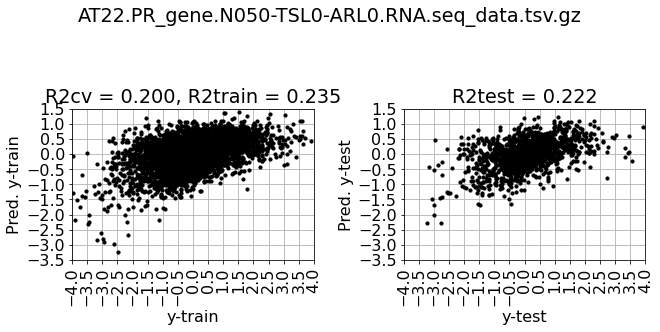

2024-08-26 11:36:23,870     INFO: Seq data |   name = AT22.PR_gene.N100-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:36:23,870     INFO: Seq data |    md5 = 0edcf8d395dbde3222a4fcdd975a2f5d
2024-08-26 11:36:23,870     INFO: Seq data | md5_gz = a0e8e05f9bb99b6759e455ab29992a00
2024-08-26 11:36:25,118     INFO: Number of all outliers in trainning data = 23
2024-08-26 11:36:25,118     INFO: Number of all outliers in test data      = 6
2024-08-26 11:36:25,248  WARNING: The ratio of `0` in '5'UTR.uAUG' is greater than 75% (85.58%).
2024-08-26 11:36:25,266  WARNING: The ratio of `0` in '5'UTR.uORF-NO' is greater than 75% (87.31%).
2024-08-26 11:36:25,269  WARNING: The ratio of `0` in '5'UTR.uORF-IO' is greater than 99% (99.92%).
2024-08-26 11:36:25,271  WARNING: The ratio of `0` in '5'UTR.uORF-OO' is greater than 90% (97.17%).


n_data = 4935, n_train = 3948, n_test = 987
Fitting 10 folds for each of 9 candidates, totalling 90 fits


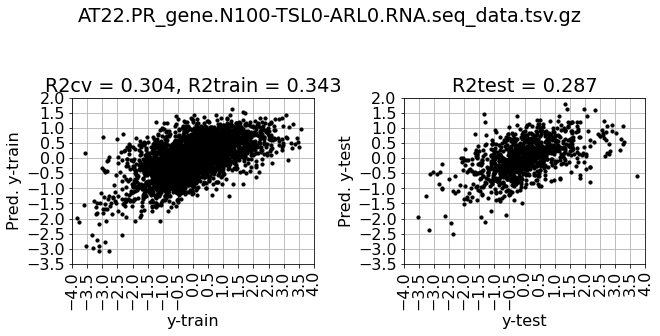

,name,n,TS_level,AR_level,R2cv,R2train,R2test,n_train,n_test
1,N100-TSL0-ARL0,100,0,0,0.303881,0.342956,0.287142,3948,987
0,N050-TSL0-ARL0,50,0,0,0.199783,0.235423,0.221659,5384,1346


,name,n,TS_level,AR_level,R2cv,R2train,R2test,n_train,n_test
1,N100-TSL0-ARL0,100,0,0,0.303881,0.342956,0.287142,3948,987
0,N050-TSL0-ARL0,50,0,0,0.199783,0.235423,0.221659,5384,1346


In [5]:
base_name = "AT22.PR_gene"

result_df_dict = {
    "name": [],
    "n": [],
    "TS_level": [],
    "AR_level": [],
    "R2cv": [],
    "R2train": [],
    "R2test": [],
    "n_train": [],
    "n_test": [],
}

for n in [50, 100]:
    # Artifact removal level: ARL
    for ar_level in [0]:
        # Threshold strictness level: TSL
        for ts_level in [0]:
            file_path = os.path.join(
                "SeqData.Gene", "%s.N%03d-TSL%s-ARL%s.RNA.seq_data.tsv.gz" % (base_name, n, ts_level, ar_level)
            )
            file_name = sylib.utils.get_file_base_name(file_path)

            seq_df, metadata = sylib.fileio.load_df(
                file_path
            )
            metadata.print_minimum_data(label="Seq data", logger=logger, logging_level="info")

            (
                cv_score, r2_train, r2_test, n_train, n_test, y_train, pred_y_train, y_test, pred_y_test
            ) = calc_pred_accuracy(
                seq_df, score_col_name="PR_gene", group_col_name=None, outlier_removal_method="Z-score"
            )
            result_df_dict["name"].append("N%03d-TSL%s-ARL%s" % (n, ts_level, ar_level))
            result_df_dict["n"].append(n)
            result_df_dict["TS_level"].append(ts_level)
            result_df_dict["AR_level"].append(ar_level)
            result_df_dict["R2cv"].append(cv_score)
            result_df_dict["R2train"].append(r2_train)
            result_df_dict["R2test"].append(r2_test)
            result_df_dict["n_train"].append(n_train)
            result_df_dict["n_test"].append(n_test)

            base = 0.5
            min_x = base * math.floor(min([min(y_train), min(y_test)]) / base)
            max_x = base * math.ceil(max([max(y_train), max(y_test)]) / base)
            min_y =  base * math.floor(min([min(pred_y_train), min(pred_y_test)]) / base)
            max_y = base * math.ceil(max([max(pred_y_train), max(pred_y_test)]) / base)
            
            width = 24/2.54
            height = 12/2.54
            fig = plt.figure(figsize=(width, height))
            
            ax1 = fig.add_subplot(1, 2, 1)
            ax1.set_aspect('equal')
            ax1.scatter(y_train, pred_y_train, s=10, color="k", marker="o")
            ax1.set_xlabel("y-train")
            ax1.set_xlim(min_x, max_x)
            ax1.set_xticks(np.arange(min_x, max_x+base/2, base))
            ax1.tick_params(axis="x", labelrotation=90)
            ax1.set_ylabel("Pred. y-train")
            ax1.set_ylim(min_y, max_y)
            ax1.set_yticks(np.arange(min_y, max_y+base/2, base))
            ax1.grid(True)
            ax1.set_title("R2cv = %.3f, R2train = %.3f" % (cv_score, r2_train))
            
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.set_aspect('equal')
            ax2.scatter(y_test, pred_y_test, s=10, color="k", marker="o")
            ax2.set_xlabel("y-test")
            ax2.set_xlim(min_x, max_x)
            ax2.set_xticks(np.arange(min_x, max_x+base/2, base))
            ax2.tick_params(axis="x", labelrotation=90)
            ax2.set_ylabel("Pred. y-test")
            ax2.set_ylim(min_y, max_y)
            ax2.set_yticks(np.arange(min_y, max_y+base/2, base))
            ax2.grid(True)
            ax2.set_title("R2test = %.3f" % r2_test)

            fig.suptitle(file_name)
            fig.tight_layout()
            plt.show()
            plt.close()
                           
result_df_22 = pd.DataFrame(result_df_dict)
display(result_df_22.sort_values("R2cv", ascending=False))
display(result_df_22.sort_values("R2test", ascending=False))


---
---
# 処理の実行（熱ストレス条件）
---

同上。


2024-08-26 11:36:36,543     INFO: Seq data |   name = AT35.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:36:36,543     INFO: Seq data |    md5 = 010f7c82fe591d99cd68f476d184876e
2024-08-26 11:36:36,543     INFO: Seq data | md5_gz = e460fe434767a99b7f1cc93cb608f96b
2024-08-26 11:36:37,818     INFO: Number of all outliers in trainning data = 13
2024-08-26 11:36:37,818     INFO: Number of all outliers in test data      = 4
2024-08-26 11:36:37,919  WARNING: The ratio of `0` in '5'UTR.uAUG' is greater than 75% (86.67%).
2024-08-26 11:36:37,919  WARNING: The ratio of `0` in '5'UTR.uORF-NO' is greater than 75% (88.35%).
2024-08-26 11:36:37,936  WARNING: The ratio of `0` in '5'UTR.uORF-IO' is greater than 99% (99.83%).
2024-08-26 11:36:37,939  WARNING: The ratio of `0` in '5'UTR.uORF-OO' is greater than 90% (97.57%).


n_data = 5060, n_train = 4048, n_test = 1012
Fitting 10 folds for each of 9 candidates, totalling 90 fits


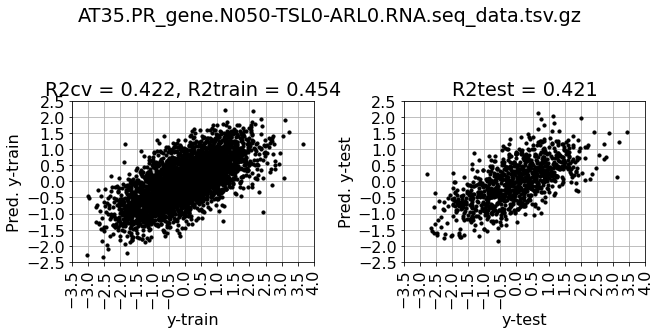

2024-08-26 11:36:40,636     INFO: Seq data |   name = AT35.PR_gene.N100-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:36:40,636     INFO: Seq data |    md5 = 26d1c1f8eb86e4bb394b5568e6b47ce2
2024-08-26 11:36:40,636     INFO: Seq data | md5_gz = 6a1f6bdf1160257e0b2bc6f2e294b968
2024-08-26 11:36:41,458     INFO: Number of all outliers in trainning data = 11
2024-08-26 11:36:41,458     INFO: Number of all outliers in test data      = 4
2024-08-26 11:36:41,549  WARNING: The ratio of `0` in '5'UTR.uAUG' is greater than 90% (90.6%).
2024-08-26 11:36:41,566  WARNING: The ratio of `0` in '5'UTR.uORF-NO' is greater than 90% (91.63%).
2024-08-26 11:36:41,571  WARNING: The ratio of `0` in '5'UTR.uORF-IO' is greater than 99% (99.89%).
2024-08-26 11:36:41,573  WARNING: The ratio of `0` in '5'UTR.uORF-OO' is greater than 90% (98.55%).


n_data = 3536, n_train = 2829, n_test = 707
Fitting 10 folds for each of 9 candidates, totalling 90 fits


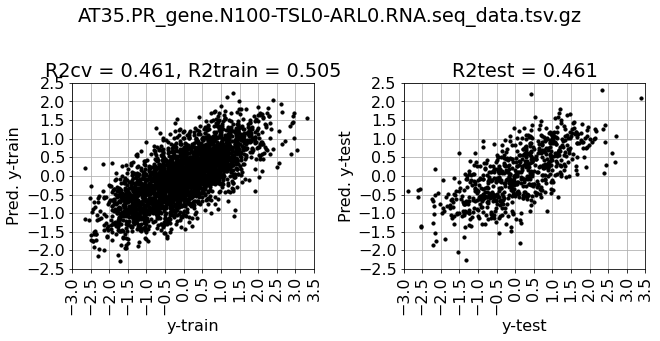

,name,n,TS_level,AR_level,R2cv,R2train,R2test,n_train,n_test
1,N100-TSL0-ARL0,100,0,0,0.460627,0.504838,0.461141,2829,707
0,N050-TSL0-ARL0,50,0,0,0.421865,0.454223,0.421307,4048,1012


,name,n,TS_level,AR_level,R2cv,R2train,R2test,n_train,n_test
1,N100-TSL0-ARL0,100,0,0,0.460627,0.504838,0.461141,2829,707
0,N050-TSL0-ARL0,50,0,0,0.421865,0.454223,0.421307,4048,1012


In [6]:
base_name = "AT35.PR_gene"

result_df_dict = {
    "name": [],
    "n": [],
    "TS_level": [],
    "AR_level": [],
    "R2cv": [],
    "R2train": [],
    "R2test": [],
    "n_train": [],
    "n_test": [],
}

for n in [50, 100]:
    # Artifact removal level: ARL
    for ar_level in [0]:
        # Threshold strictness level: TSL
        for ts_level in [0]:
            file_path = os.path.join(
                "SeqData.Gene", "%s.N%03d-TSL%s-ARL%s.RNA.seq_data.tsv.gz" % (base_name, n, ts_level, ar_level)
            )
            file_name = sylib.utils.get_file_base_name(file_path)

            seq_df, metadata = sylib.fileio.load_df(
                file_path
            )
            metadata.print_minimum_data(label="Seq data", logger=logger, logging_level="info")

            (
                cv_score, r2_train, r2_test, n_train, n_test, y_train, pred_y_train, y_test, pred_y_test
            ) = calc_pred_accuracy(
                seq_df, score_col_name="PR_gene", group_col_name=None, outlier_removal_method="Z-score"
            )
            result_df_dict["name"].append("N%03d-TSL%s-ARL%s" % (n, ts_level, ar_level))
            result_df_dict["n"].append(n)
            result_df_dict["TS_level"].append(ts_level)
            result_df_dict["AR_level"].append(ar_level)
            result_df_dict["R2cv"].append(cv_score)
            result_df_dict["R2train"].append(r2_train)
            result_df_dict["R2test"].append(r2_test)
            result_df_dict["n_train"].append(n_train)
            result_df_dict["n_test"].append(n_test)

            base = 0.5
            min_x = base * math.floor(min([min(y_train), min(y_test)]) / base)
            max_x = base * math.ceil(max([max(y_train), max(y_test)]) / base)
            min_y =  base * math.floor(min([min(pred_y_train), min(pred_y_test)]) / base)
            max_y = base * math.ceil(max([max(pred_y_train), max(pred_y_test)]) / base)
            
            width = 24/2.54
            height = 12/2.54
            fig = plt.figure(figsize=(width, height))
            
            ax1 = fig.add_subplot(1, 2, 1)
            ax1.set_aspect('equal')
            ax1.scatter(y_train, pred_y_train, s=10, color="k", marker="o")
            ax1.set_xlabel("y-train")
            ax1.set_xlim(min_x, max_x)
            ax1.set_xticks(np.arange(min_x, max_x+base/2, base))
            ax1.tick_params(axis="x", labelrotation=90)
            ax1.set_ylabel("Pred. y-train")
            ax1.set_ylim(min_y, max_y)
            ax1.set_yticks(np.arange(min_y, max_y+base/2, base))
            ax1.grid(True)
            ax1.set_title("R2cv = %.3f, R2train = %.3f" % (cv_score, r2_train))
            
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.set_aspect('equal')
            ax2.scatter(y_test, pred_y_test, s=10, color="k", marker="o")
            ax2.set_xlabel("y-test")
            ax2.set_xlim(min_x, max_x)
            ax2.set_xticks(np.arange(min_x, max_x+base/2, base))
            ax2.tick_params(axis="x", labelrotation=90)
            ax2.set_ylabel("Pred. y-test")
            ax2.set_ylim(min_y, max_y)
            ax2.set_yticks(np.arange(min_y, max_y+base/2, base))
            ax2.grid(True)
            ax2.set_title("R2test = %.3f" % r2_test)

            fig.suptitle(file_name)
            fig.tight_layout()
            plt.show()
            plt.close()
                           
result_df_35 = pd.DataFrame(result_df_dict)
display(result_df_35.sort_values("R2cv", ascending=False))
display(result_df_35.sort_values("R2test", ascending=False))


---
---
# 結論
---

**結局どのデータを使うべきなのか？ →　N100。**


In [8]:
display(result_df_22.sort_values("R2cv", ascending=False))
display(result_df_35.sort_values("R2cv", ascending=False))


,name,n,TS_level,AR_level,R2cv,R2train,R2test,n_train,n_test
1,N100-TSL0-ARL0,100,0,0,0.303881,0.342956,0.287142,3948,987
0,N050-TSL0-ARL0,50,0,0,0.199783,0.235423,0.221659,5384,1346


,name,n,TS_level,AR_level,R2cv,R2train,R2test,n_train,n_test
1,N100-TSL0-ARL0,100,0,0,0.460627,0.504838,0.461141,2829,707
0,N050-TSL0-ARL0,50,0,0,0.421865,0.454223,0.421307,4048,1012
